# Steering Model Test & Debug
조향 액추에이터 모델 테스트 및 디버깅 노트북

## 목적
- SteeringModel 동작 확인
- **입력**: T_str (조향 토크), T_align (셀프 얼라이닝 토크) → **출력**: δ (조향 각도), δ̇ (조향 각속도)
- 2차 동역학 방정식: `J*δ̈ + B*δ̇ + K*δ = T_str - T_align`

In [12]:
# 필요한 라이브러리 import
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 프로젝트 루트를 Python path에 추가
project_root = Path.cwd().parent.parent.parent.parent.parent
sys.path.insert(0, str(project_root))

# SteeringModel import
from vehicle_sim.models.e_corner.steering.steering_model import SteeringModel
from vehicle_sim.utils.config_loader import load_param

print("Import 성공!")

Import 성공!


## 1. 기본 동작 테스트
SteeringModel 생성 및 기본 파라미터 확인

In [13]:
# YAML에서 steering 파라미터 로드 (left 휠 사용)
steering_param = load_param('steering', None)
left_param = steering_param.copy()
left_param['max_angle_pos'] = steering_param['left']['max_angle_pos']
left_param['max_angle_neg'] = steering_param['left']['max_angle_neg']

# 모델 생성
steering = SteeringModel(config=left_param)

print("=== Steering Model Parameters (Left Wheel) ===")
print(f"등가 관성 J_cq: {steering.params.J_cq} kg·m²")
print(f"점성 댐핑 B_cq: {steering.params.B_cq} N·m·s/rad")
print(f"최대 조향각 (+): {np.rad2deg(steering.params.max_angle_pos):.1f}°")
print(f"최대 조향각 (-): {np.rad2deg(steering.params.max_angle_neg):.1f}°")
print(f"최대 조향 속도: {np.rad2deg(steering.params.max_rate):.1f} deg/s")

print("\n=== 초기 상태 ===")
print(f"Steering 상태: {steering.get_state()}")


=== Steering Model Parameters (Left Wheel) ===
등가 관성 J_cq: 0.04 kg·m²
점성 댐핑 B_cq: 0.072 N·m·s/rad
최대 조향각 (+): 98.0°
최대 조향각 (-): -60.0°
최대 조향 속도: 360.0 deg/s

=== 초기 상태 ===
Steering 상태: {'steering_angle': 0.0, 'steering_rate': 0.0, 'steering_torque': 0.0, 'self_aligning_torque': 0.0}


## 2. 스텝 응답 테스트 (T_align = 0)
**입력**: T_str (스텝), T_align = 0  
**출력**: δ, δ̇

In [14]:
# 시뮬레이션 설정
dt = 0.0001
t_end = 4.0
time_steps = int(t_end / dt)
time = np.arange(0, t_end, dt)

# 데이터 저장 배열
delta_history = np.zeros(time_steps)
delta_dot_history = np.zeros(time_steps)
T_str_history = np.zeros(time_steps)
T_align_history = np.zeros(time_steps)

# 모델 리셋
steering.reset()

# 시뮬레이션 실행
for i in range(time_steps):
    t = time[i]
    
    # [입력] 스텝 토크 (0.5초부터 10 N·m)
    T_str = 10.0 if t >= 0.5 else 0.0
    T_align = 0.0  # 얼라이닝 토크 없음
    
    # 업데이트
    delta = steering.update(dt, T_str, T_align)
    delta_dot = steering.state.steering_rate
    
    # 저장
    delta_history[i] = delta
    delta_dot_history[i] = delta_dot
    T_str_history[i] = T_str
    T_align_history[i] = T_align

print("스텝 응답 시뮬레이션 완료!")
print(f"최종 조향각: {np.rad2deg(delta_history[-1]):.2f}°")

스텝 응답 시뮬레이션 완료!
최종 조향각: 98.00°


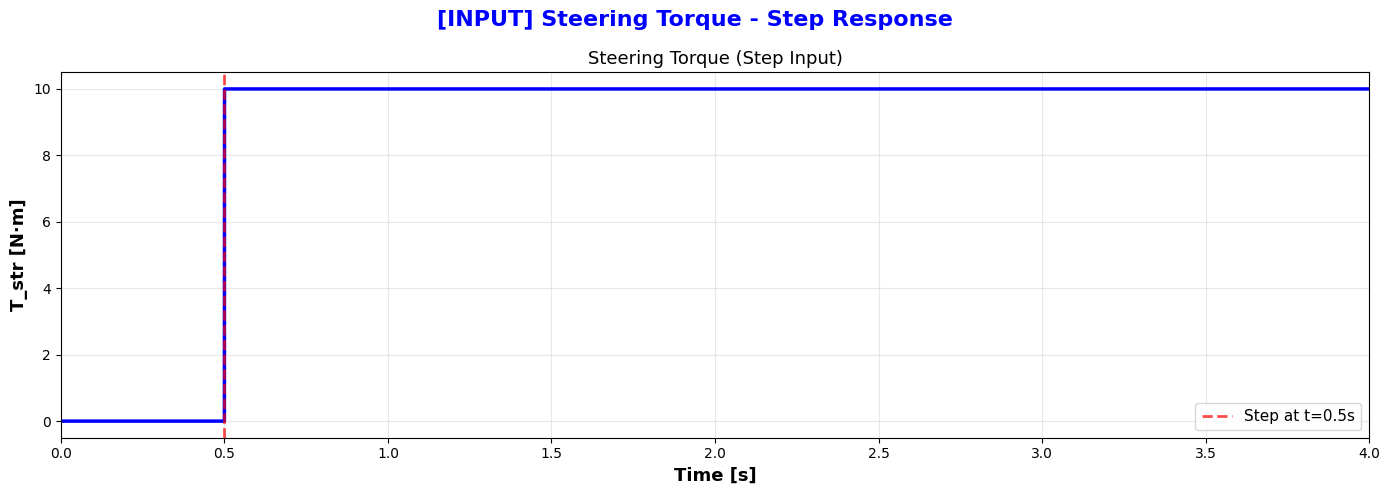

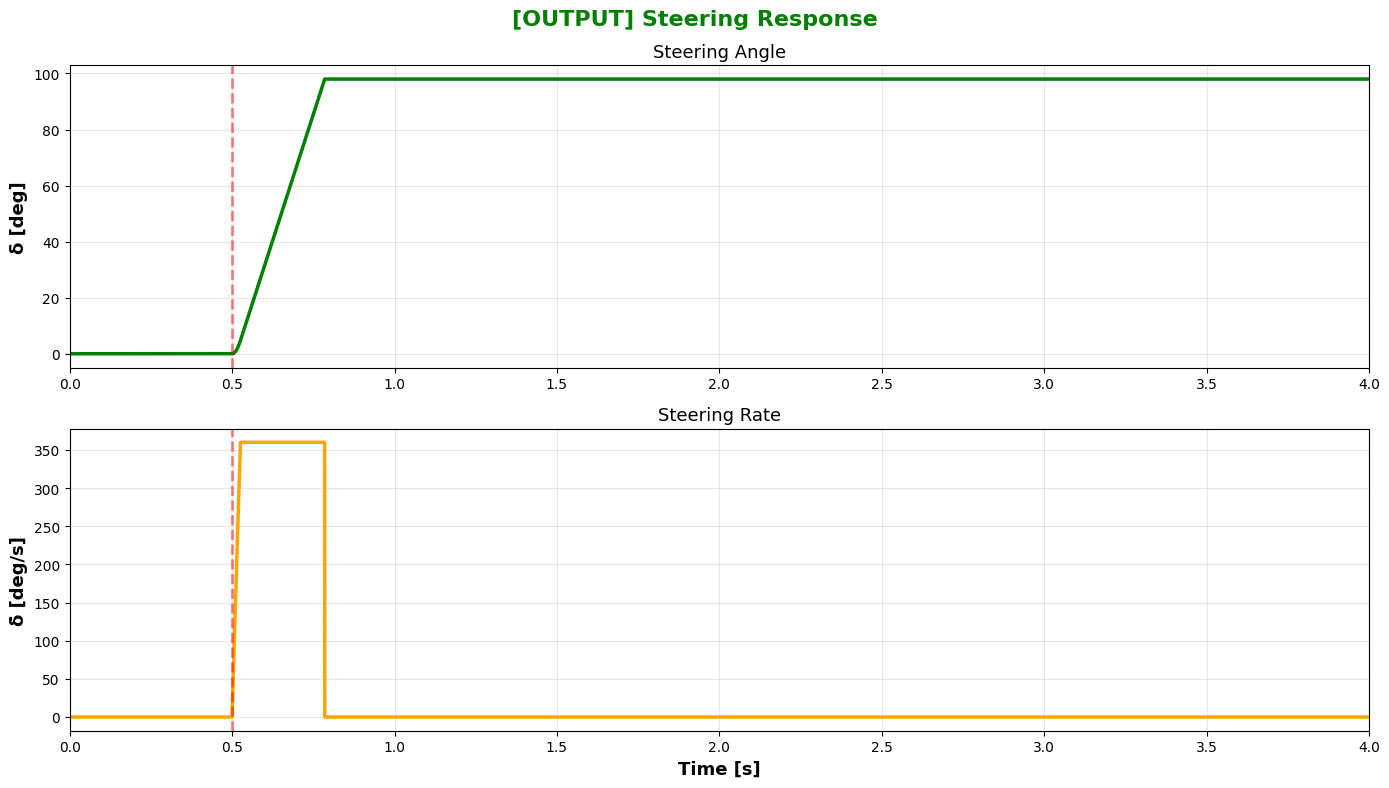

In [15]:
# ========================================
# [입력 INPUT] 시각화
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle('[INPUT] Steering Torque - Step Response', fontsize=16, fontweight='bold', color='blue')

ax.plot(time, T_str_history, 'b-', linewidth=2.5)
ax.set_xlabel('Time [s]', fontsize=13, fontweight='bold')
ax.set_ylabel('T_str [N·m]', fontsize=13, fontweight='bold')
ax.set_title('Steering Torque (Step Input)', fontsize=13)
ax.grid(True, alpha=0.3)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Step at t=0.5s')
ax.legend(fontsize=11)
ax.set_xlim([0, t_end])

plt.tight_layout()
plt.show()

# ========================================
# [출력 OUTPUT] 시각화
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('[OUTPUT] Steering Response', fontsize=16, fontweight='bold', color='green')

# 조향 각도
axes[0].plot(time, np.rad2deg(delta_history), 'g-', linewidth=2.5)
axes[0].set_ylabel('δ [deg]', fontsize=13, fontweight='bold')
axes[0].set_title('Steering Angle', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, linewidth=2)
axes[0].set_xlim([0, t_end])

# 조향 각속도
axes[1].plot(time, np.rad2deg(delta_dot_history), 'orange', linewidth=2.5)
axes[1].set_xlabel('Time [s]', fontsize=13, fontweight='bold')
axes[1].set_ylabel('δ̇ [deg/s]', fontsize=13, fontweight='bold')
axes[1].set_title('Steering Rate', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, linewidth=2)
axes[1].set_xlim([0, t_end])

plt.tight_layout()
plt.show()

## 3. 얼라이닝 토크 영향 테스트
**입력**: T_str (일정), T_align (각도 비례 복원 토크)  
**출력**: δ, δ̇

임의 모델: `T_align = C_align × δ` (타이어 복원 토크 모사)

In [16]:
# 시뮬레이션 설정
dt = 0.001
t_end = 3.0
time_steps = int(t_end / dt)
time = np.arange(0, t_end, dt)

# 얼라이닝 토크 계수 (각도 비례)
C_align = 5.0  # [N·m/rad]

# 데이터 저장
delta_history = np.zeros(time_steps)
delta_dot_history = np.zeros(time_steps)
T_str_history = np.zeros(time_steps)
T_align_history = np.zeros(time_steps)

# 모델 리셋
steering.reset()

# 시뮬레이션
for i in range(time_steps):
    t = time[i]
    
    # [입력] 일정한 조향 토크
    T_str = 15.0 if t >= 0.5 else 0.0
    
    # [입력] 얼라이닝 토크 (각도 비례)
    if i > 0:
        T_align = C_align * delta_history[i-1]
    else:
        T_align = 0.0
    
    # 업데이트
    delta = steering.update(dt, T_str, T_align)
    delta_dot = steering.state.steering_rate
    
    # 저장
    delta_history[i] = delta
    delta_dot_history[i] = delta_dot
    T_str_history[i] = T_str
    T_align_history[i] = T_align

print("얼라이닝 토크 시뮬레이션 완료!")
print(f"최종 조향각: {np.rad2deg(delta_history[-1]):.2f}°")
print(f"최종 얼라이닝 토크: {T_align_history[-1]:.2f} N·m")

얼라이닝 토크 시뮬레이션 완료!
최종 조향각: 98.00°
최종 얼라이닝 토크: 8.55 N·m


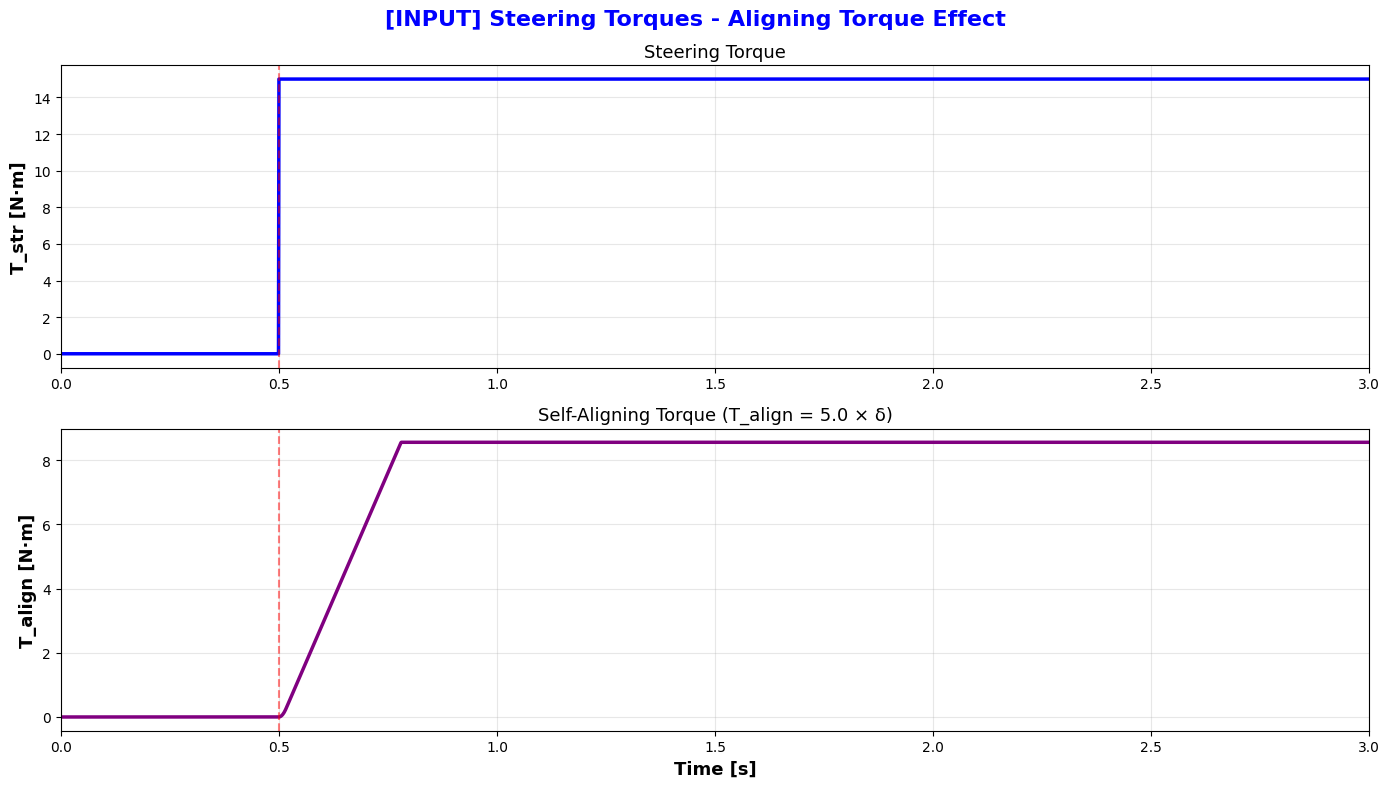

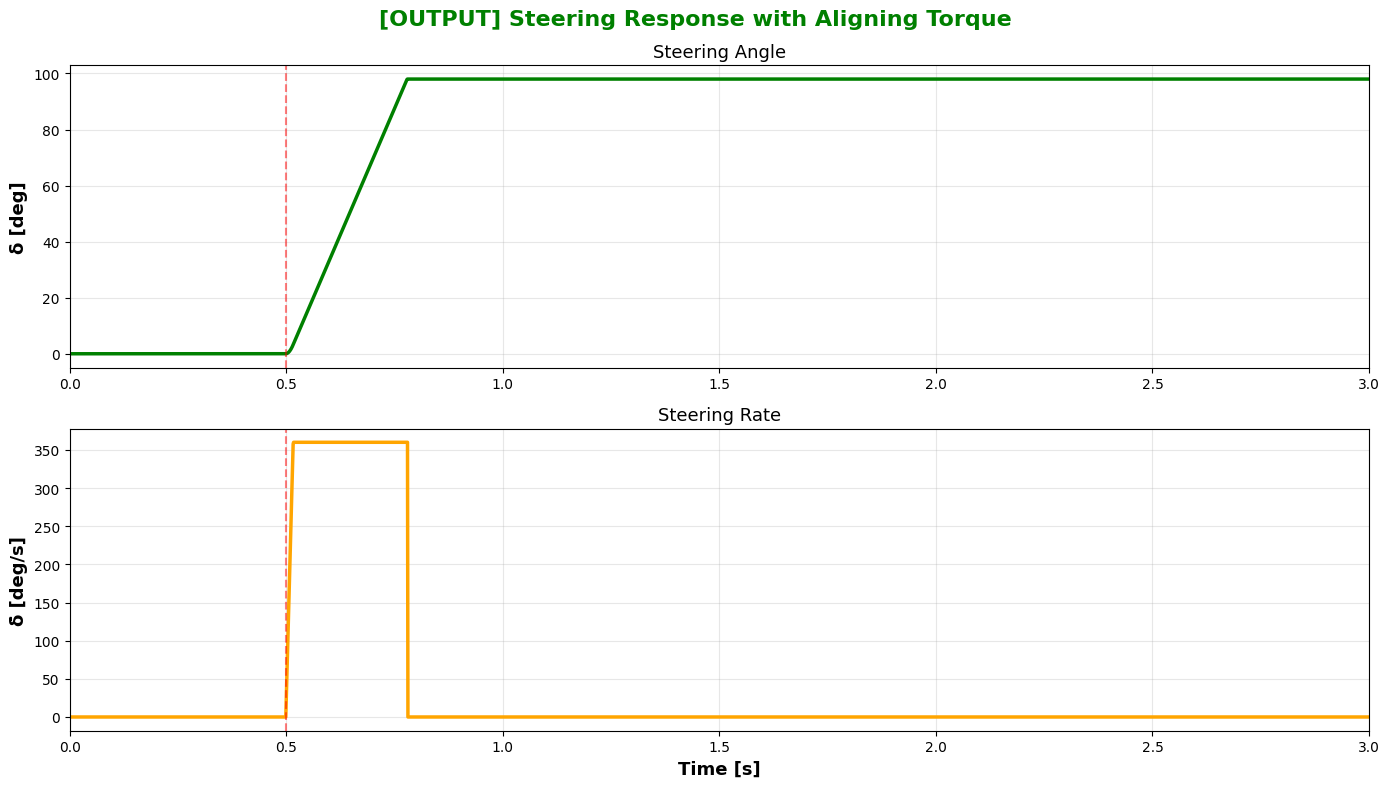

In [17]:
# ========================================
# [입력 INPUT] 시각화
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('[INPUT] Steering Torques - Aligning Torque Effect', fontsize=16, fontweight='bold', color='blue')

# 입력 1: 조향 토크
axes[0].plot(time, T_str_history, 'b-', linewidth=2.5)
axes[0].set_ylabel('T_str [N·m]', fontsize=13, fontweight='bold')
axes[0].set_title('Steering Torque', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlim([0, t_end])

# 입력 2: 얼라이닝 토크 (계산값)
axes[1].plot(time, T_align_history, 'purple', linewidth=2.5)
axes[1].set_xlabel('Time [s]', fontsize=13, fontweight='bold')
axes[1].set_ylabel('T_align [N·m]', fontsize=13, fontweight='bold')
axes[1].set_title(f'Self-Aligning Torque (T_align = {C_align} × δ)', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlim([0, t_end])

plt.tight_layout()
plt.show()

# ========================================
# [출력 OUTPUT] 시각화
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('[OUTPUT] Steering Response with Aligning Torque', fontsize=16, fontweight='bold', color='green')

# 조향 각도
axes[0].plot(time, np.rad2deg(delta_history), 'g-', linewidth=2.5)
axes[0].set_ylabel('δ [deg]', fontsize=13, fontweight='bold')
axes[0].set_title('Steering Angle', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlim([0, t_end])

# 조향 각속도
axes[1].plot(time, np.rad2deg(delta_dot_history), 'orange', linewidth=2.5)
axes[1].set_xlabel('Time [s]', fontsize=13, fontweight='bold')
axes[1].set_ylabel('δ̇ [deg/s]', fontsize=13, fontweight='bold')
axes[1].set_title('Steering Rate', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlim([0, t_end])

plt.tight_layout()
plt.show()

## 4. 각도/속도 제한 테스트
**입력**: T_str (큰 스텝)  
**출력**: δ (각도 제한), δ̇ (속도 제한)

In [18]:
# 시뮬레이션 설정
dt = 0.001
t_end = 3.0
time_steps = int(t_end / dt)
time = np.arange(0, t_end, dt)

# 데이터 저장
delta_history = np.zeros(time_steps)
delta_dot_history = np.zeros(time_steps)
T_str_history = np.zeros(time_steps)

# 모델 리셋
steering.reset()

# 시뮬레이션
for i in range(time_steps):
    t = time[i]
    
    # [입력] 매우 큰 조향 토크 (제한 테스트)
    T_str = 100.0 if t >= 0.2 else 0.0
    T_align = 0.0
    
    # 업데이트
    delta = steering.update(dt, T_str, T_align)
    delta_dot = steering.state.steering_rate
    
    # 저장
    delta_history[i] = delta
    delta_dot_history[i] = delta_dot
    T_str_history[i] = T_str

print("제한 테스트 시뮬레이션 완료!")
print(f"최대 조향각: {np.rad2deg(delta_history.max()):.2f}° (제한: {np.rad2deg(steering.params.max_angle_pos):.2f}°)")
print(f"최대 조향 속도: {np.rad2deg(delta_dot_history.max()):.2f} deg/s (제한: {np.rad2deg(steering.params.max_rate):.2f} deg/s)")

제한 테스트 시뮬레이션 완료!
최대 조향각: 98.00° (제한: 98.00°)
최대 조향 속도: 360.00 deg/s (제한: 360.00 deg/s)


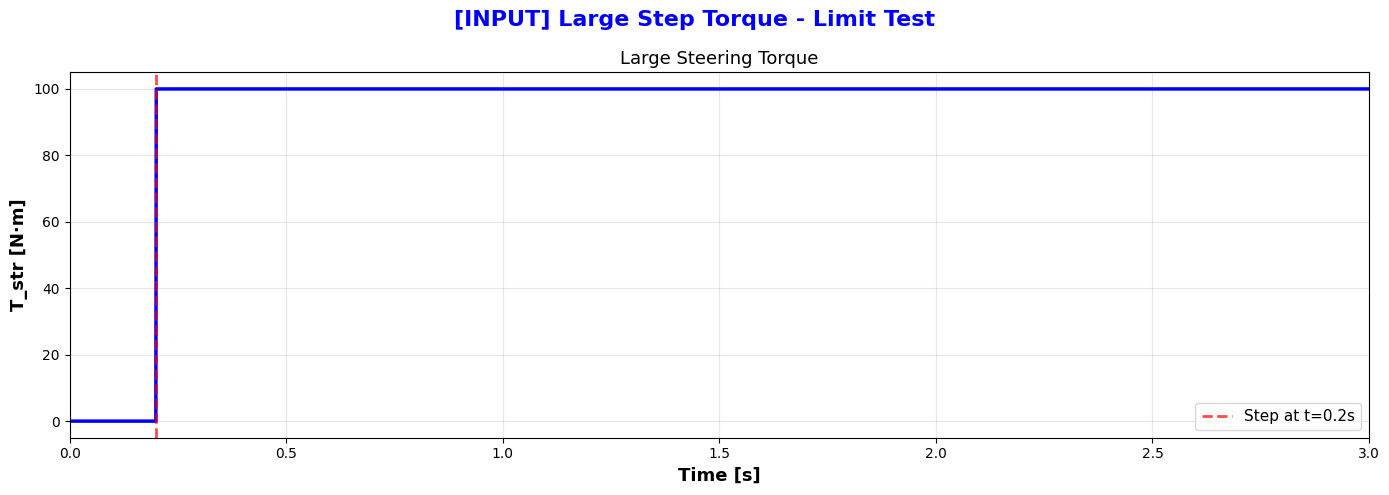

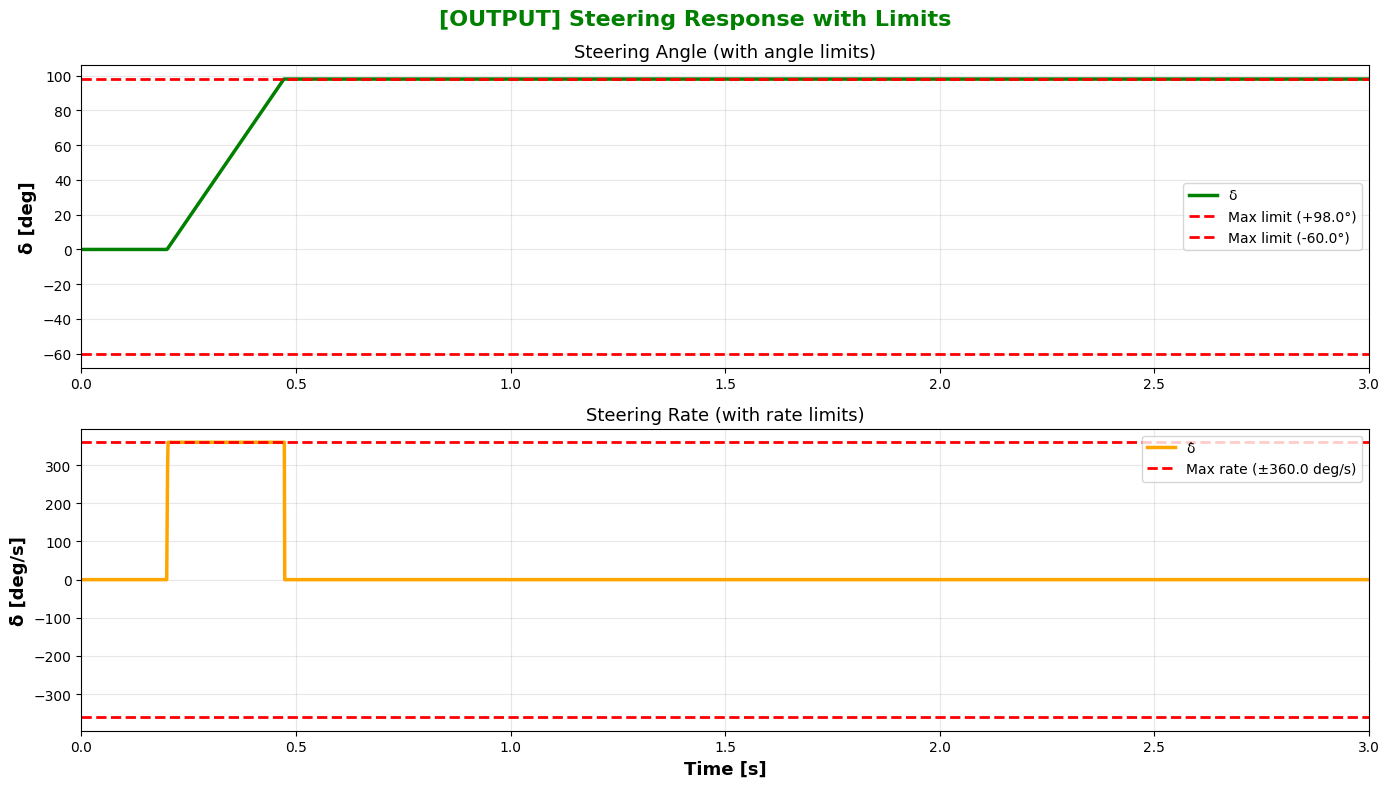

In [19]:
# ========================================
# [입력 INPUT] 시각화
# ========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle('[INPUT] Large Step Torque - Limit Test', fontsize=16, fontweight='bold', color='blue')

ax.plot(time, T_str_history, 'b-', linewidth=2.5)
ax.set_xlabel('Time [s]', fontsize=13, fontweight='bold')
ax.set_ylabel('T_str [N·m]', fontsize=13, fontweight='bold')
ax.set_title('Large Steering Torque', fontsize=13)
ax.grid(True, alpha=0.3)
ax.axvline(x=0.2, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Step at t=0.2s')
ax.legend(fontsize=11)
ax.set_xlim([0, t_end])

plt.tight_layout()
plt.show()

# ========================================
# [출력 OUTPUT] 시각화 - 제한 확인
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('[OUTPUT] Steering Response with Limits', fontsize=16, fontweight='bold', color='green')

# 조향 각도 (각도 제한 표시)
axes[0].plot(time, np.rad2deg(delta_history), 'g-', linewidth=2.5, label='δ')
axes[0].axhline(y=np.rad2deg(steering.params.max_angle_pos), color='red', linestyle='--', linewidth=2, label=f'Max limit (+{np.rad2deg(steering.params.max_angle_pos):.1f}°)')
axes[0].axhline(y=np.rad2deg(steering.params.max_angle_neg), color='red', linestyle='--', linewidth=2, label=f'Max limit ({np.rad2deg(steering.params.max_angle_neg):.1f}°)')
axes[0].set_ylabel('δ [deg]', fontsize=13, fontweight='bold')
axes[0].set_title('Steering Angle (with angle limits)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, t_end])

# 조향 각속도 (속도 제한 표시)
axes[1].plot(time, np.rad2deg(delta_dot_history), 'orange', linewidth=2.5, label='δ̇')
axes[1].axhline(y=np.rad2deg(steering.params.max_rate), color='red', linestyle='--', linewidth=2, label=f'Max rate (±{np.rad2deg(steering.params.max_rate):.1f} deg/s)')
axes[1].axhline(y=-np.rad2deg(steering.params.max_rate), color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Time [s]', fontsize=13, fontweight='bold')
axes[1].set_ylabel('δ̇ [deg/s]', fontsize=13, fontweight='bold')
axes[1].set_title('Steering Rate (with rate limits)', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, t_end])

plt.tight_layout()
plt.show()

## 5. 사인파 입력 응답
**입력**: T_str (사인파), T_align (속도 비례)  
**출력**: δ, δ̇

In [20]:
# 시뮬레이션 설정
dt = 0.001
t_end = 5.0
time_steps = int(t_end / dt)
time = np.arange(0, t_end, dt)

# 얼라이닝 토크 계수 (속도 비례)
C_align_damping = 3.0  # [N·m·s/rad]

# 데이터 저장
delta_history = np.zeros(time_steps)
delta_dot_history = np.zeros(time_steps)
T_str_history = np.zeros(time_steps)
T_align_history = np.zeros(time_steps)

# 모델 리셋
steering.reset()

# 시뮬레이션
for i in range(time_steps):
    t = time[i]
    
    # [입력] 사인파 조향 토크
    T_str = 15.0 * np.sin(2 * np.pi * 0.5 * t)
    
    # [입력] 얼라이닝 토크 (속도 비례 댐핑)
    if i > 0:
        T_align = 0.0
    else:
        T_align = 0.0
    
    # 업데이트
    delta = steering.update(dt, T_str, T_align)
    delta_dot = steering.state.steering_rate
    
    # 저장
    delta_history[i] = delta
    delta_dot_history[i] = delta_dot
    T_str_history[i] = T_str
    T_align_history[i] = T_align

print("사인파 응답 시뮬레이션 완료!")

사인파 응답 시뮬레이션 완료!


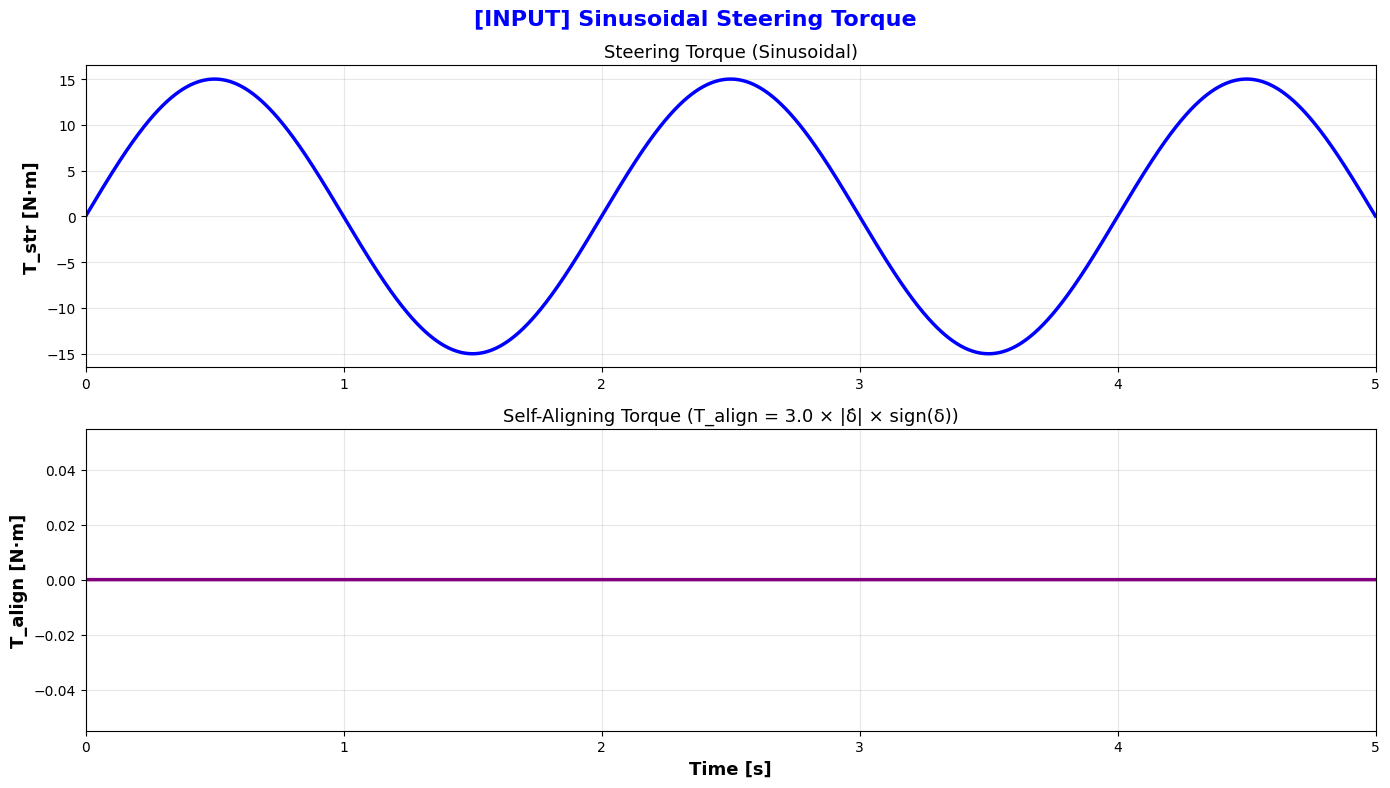

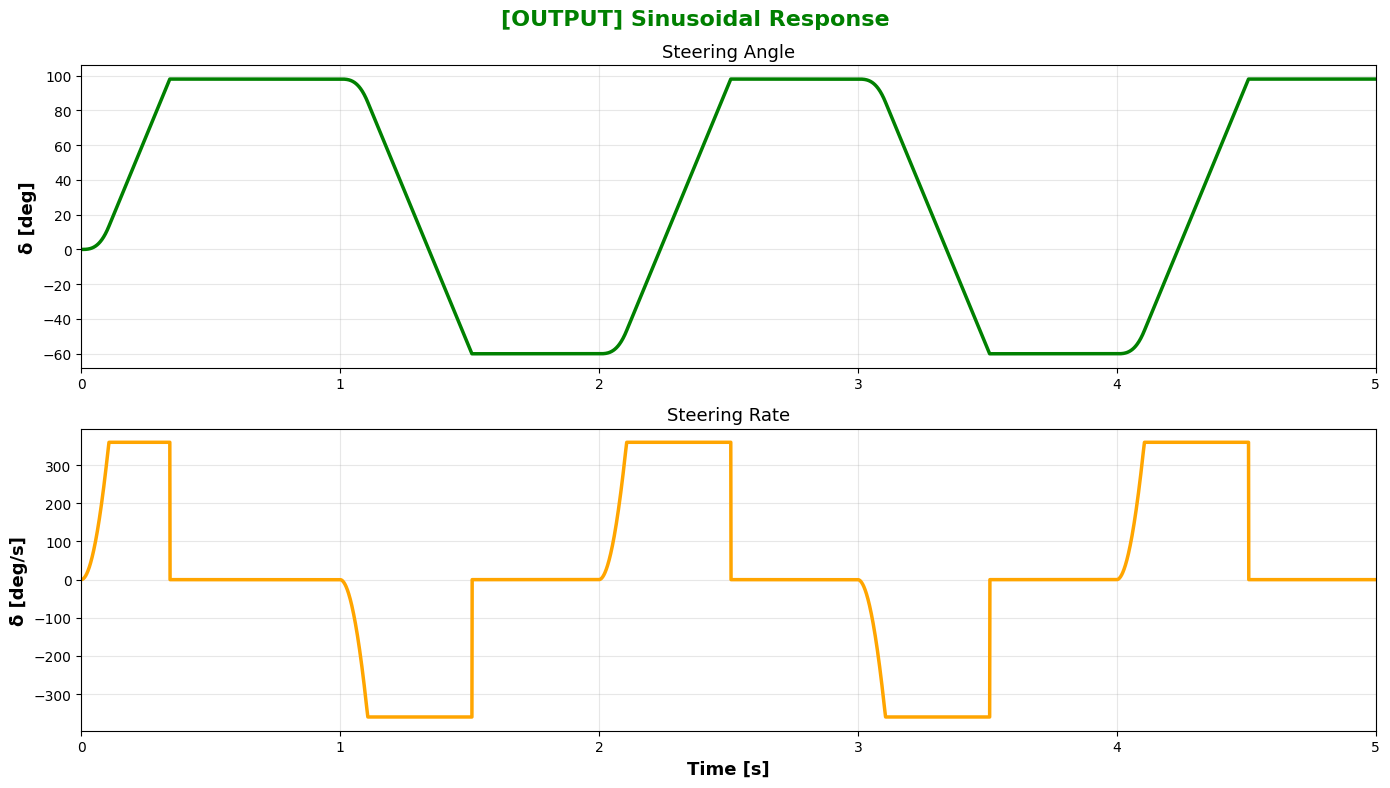

In [21]:
# ========================================
# [입력 INPUT] 시각화
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('[INPUT] Sinusoidal Steering Torque', fontsize=16, fontweight='bold', color='blue')

# 입력 1: 사인파 조향 토크
axes[0].plot(time, T_str_history, 'b-', linewidth=2.5)
axes[0].set_ylabel('T_str [N·m]', fontsize=13, fontweight='bold')
axes[0].set_title('Steering Torque (Sinusoidal)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, t_end])

# 입력 2: 얼라이닝 토크 (속도 비례)
axes[1].plot(time, T_align_history, 'purple', linewidth=2.5)
axes[1].set_xlabel('Time [s]', fontsize=13, fontweight='bold')
axes[1].set_ylabel('T_align [N·m]', fontsize=13, fontweight='bold')
axes[1].set_title(f'Self-Aligning Torque (T_align = {C_align_damping} × |δ̇| × sign(δ))', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, t_end])

plt.tight_layout()
plt.show()

# ========================================
# [출력 OUTPUT] 시각화
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('[OUTPUT] Sinusoidal Response', fontsize=16, fontweight='bold', color='green')

# 조향 각도
axes[0].plot(time, np.rad2deg(delta_history), 'g-', linewidth=2.5)
axes[0].set_ylabel('δ [deg]', fontsize=13, fontweight='bold')
axes[0].set_title('Steering Angle', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, t_end])

# 조향 각속도
axes[1].plot(time, np.rad2deg(delta_dot_history), 'orange', linewidth=2.5)
axes[1].set_xlabel('Time [s]', fontsize=13, fontweight='bold')
axes[1].set_ylabel('δ̇ [deg/s]', fontsize=13, fontweight='bold')
axes[1].set_title('Steering Rate', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, t_end])

plt.tight_layout()
plt.show()

## 6. 요약

### 입력-출력 관계:
```
[입력] T_str, T_align → [SteeringModel] → [출력] δ, δ̇
                        (J*δ̈ + B*δ̇ + K*δ = T_str - T_align)
```

### 검증 완료:
- ✓ 스텝 응답 (2차 시스템)
- ✓ 얼라이닝 토크 영향
- ✓ 각도/속도 제한
- ✓ 사인파 입력 추종

In [22]:
print("=" * 60)
print("Steering Model Test Summary")
print("=" * 60)
print("\n✓ 모델: 2차 동역학 시스템")
print("✓ 스텝 응답 테스트: 통과")
print("✓ 얼라이닝 토크 영향 테스트: 통과")
print("✓ 각도/속도 제한 테스트: 통과")
print("✓ 사인파 입력 응답: 통과")
print("\n모든 테스트 완료!")
print("=" * 60)

Steering Model Test Summary

✓ 모델: 2차 동역학 시스템
✓ 스텝 응답 테스트: 통과
✓ 얼라이닝 토크 영향 테스트: 통과
✓ 각도/속도 제한 테스트: 통과
✓ 사인파 입력 응답: 통과

모든 테스트 완료!
